In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("LinearRegressionLab").getOrCreate()

In [5]:
#Load the dataset
data = spark.read.csv("california_housing.csv", header=True, inferSchema=True)
data.show(5)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+---------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|ocean_proximity|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+---------------+------------------+
|  -122.23|   37.88|                41|        880|           129|       322|       126|       8.3252|       NEAR BAY|            452600|
|  -122.22|   37.86|                21|       7099|          1106|      2401|      1138|       8.3014|       NEAR BAY|            358500|
|  -122.24|   37.85|                52|       1467|           190|       496|       177|       7.2574|       NEAR BAY|            352100|
|  -122.25|   37.85|                52|       1274|           235|       558|       219|       5.6431|       NEAR BAY|            341300|
|  -122.25|   37.85|              

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["median_income", "housing_median_age", "total_rooms", "population"],
    outputCol="features"
)

output = assembler.transform(data).select("features", "median_house_value")
output.show(5)

In [6]:
from pyspark.ml.feature import VectorAssembler

In [7]:
assembler = VectorAssembler(
    inputCols=["median_income", "housing_median_age", "total_rooms", "population"],
    outputCol="features"
)

In [8]:
output = assembler.transform(data).select("features", "median_house_value")

In [9]:
output.show(5)

+--------------------+------------------+
|            features|median_house_value|
+--------------------+------------------+
|[8.3252,41.0,880....|            452600|
|[8.3014,21.0,7099...|            358500|
|[7.2574,52.0,1467...|            352100|
|[5.6431,52.0,1274...|            341300|
|[3.8462,52.0,1627...|            342200|
+--------------------+------------------+
only showing top 5 rows



In [10]:
train_data, test_data = output.randomSplit([0.7, 0.3])

In [ ]:
from pyspark.ml.regression import LinearRegression

In [11]:
# Drop rows with missing values
data = data.na.drop()

# Select relevant features for modeling
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["median_income", "housing_median_age", "total_rooms", "population"],
    outputCol="features"
)

output = assembler.transform(data).select("features", "median_house_value")

In [12]:
train_data, test_data = output.randomSplit([0.7, 0.3])

In [14]:
from pyspark.ml.regression import LinearRegression

# Initialize the model
lr = LinearRegression(featuresCol="features", labelCol="median_house_value")

# Train the model
lr_model = lr.fit(train_data)

In [15]:
print("Coefficients:", lr_model.coefficients)
print("Intercept:", lr_model.intercept)

Coefficients: [41130.27954357784,2024.6297421223896,9.374249009445066,-11.564702030592832]
Intercept: -18804.244760120084


In [16]:
predictions = lr_model.transform(test_data)
predictions.select("features", "prediction", "median_house_value").show(5)

+--------------------+------------------+------------------+
|            features|        prediction|median_house_value|
+--------------------+------------------+------------------+
|[0.4999,23.0,333....| 49155.07997061727|            100000|
|[0.4999,29.0,515....| 34189.73428283327|            500001|
|[0.4999,36.0,15.0...| 74610.59590480328|            162500|
|[0.4999,52.0,62.0...|107109.88512331825|            112500|
|[0.536,4.0,42.0,9.0]|11629.740183848557|             42500|
+--------------------+------------------+------------------+
only showing top 5 rows



In [17]:
from pyspark.ml.evaluation import RegressionEvaluator

# Evaluate RMSE
rmse_evaluator = RegressionEvaluator(
    labelCol="median_house_value", predictionCol="prediction", metricName="rmse"
)
rmse = rmse_evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE):", rmse)

# Evaluate R²
r2_evaluator = RegressionEvaluator(
    labelCol="median_house_value", predictionCol="prediction", metricName="r2"
)
r2 = r2_evaluator.evaluate(predictions)
print("R²:", r2)

Root Mean Squared Error (RMSE): 81080.92211947372
R²: 0.49297122818599326


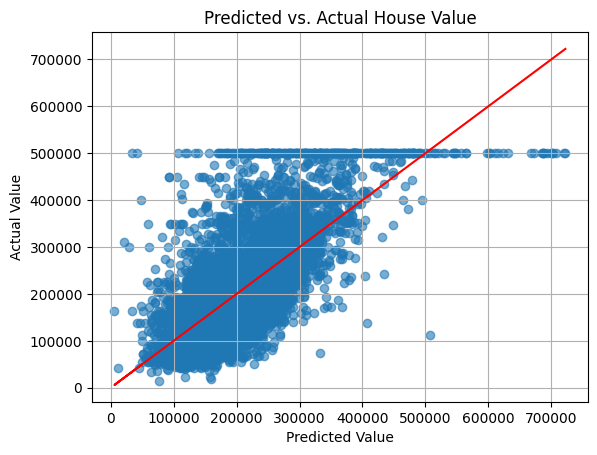

In [18]:
# Convert predictions to Pandas
pred_df = predictions.select("prediction", "median_house_value").toPandas()

# Plot best-fit line
import matplotlib.pyplot as plt

plt.scatter(pred_df["prediction"], pred_df["median_house_value"], alpha=0.6)
plt.plot(pred_df["prediction"], pred_df["prediction"], color="red")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Predicted vs. Actual House Value")
plt.grid(True)
plt.show()

In [28]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaled_data = scaler.fit(assembled_data).transform(assembled_data)

In [29]:
# Get coefficients
coeffs = lr_model.coefficients

# Match them to feature names
feature_names = ["median_income", "total_rooms", "population", ...]  # your inputCols
for name, coef in zip(feature_names, coeffs):
    print(f"{name}: {coef}")

median_income: 41130.27954357784
total_rooms: 2024.6297421223896
population: 9.374249009445066
Ellipsis: -11.564702030592832


In [36]:
# STEP 1: Start Spark session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("HouseValuePrediction").getOrCreate()

# STEP 2: Create input DataFrame
from pyspark.sql import Row
input_df = spark.createDataFrame([Row(median_income=6.5)])

# STEP 3: Assemble feature vector
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=["median_income"], outputCol="features")
assembled_input = assembler.transform(input_df)

# STEP 4: Load or train your Linear Regression model
# If you already trained and saved your model, load it like this:
# from pyspark.ml.regression import LinearRegressionModel
# lr_model = LinearRegressionModel.load("/path/to/your/model")

# If you haven't trained it yet, here's a quick training example:
from pyspark.ml.regression import LinearRegression

# Sample training data (replace with your actual dataset)
training_data = spark.createDataFrame([
    Row(median_income=1.5, median_house_value=100000.0),
    Row(median_income=3.0, median_house_value=150000.0),
    Row(median_income=6.0, median_house_value=280000.0),
    Row(median_income=8.0, median_house_value=350000.0)
])

# Assemble training features
training_assembled = assembler.transform(training_data)

# Train the model
lr = LinearRegression(featuresCol="features", labelCol="median_house_value")
lr_model = lr.fit(training_assembled)

# STEP 5: Predict house value
prediction_result = lr_model.transform(assembled_input)
prediction_result.select("median_income", "prediction").show()

+-------------+-----------------+
|median_income|       prediction|
+-------------+-----------------+
|          6.5|293722.6277372263|
+-------------+-----------------+



In [44]:
# Read CSV with header and infer schema
housing_df = spark.read.csv("california_housing.csv", header=True, inferSchema=True)

# Preview the data
housing_df.show(5)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+---------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|ocean_proximity|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+---------------+------------------+
|  -122.23|   37.88|                41|        880|           129|       322|       126|       8.3252|       NEAR BAY|            452600|
|  -122.22|   37.86|                21|       7099|          1106|      2401|      1138|       8.3014|       NEAR BAY|            358500|
|  -122.24|   37.85|                52|       1467|           190|       496|       177|       7.2574|       NEAR BAY|            352100|
|  -122.25|   37.85|                52|       1274|           235|       558|       219|       5.6431|       NEAR BAY|            341300|
|  -122.25|   37.85|              

In [45]:
# Filter exact match
actual_df = housing_df.filter(housing_df.median_income == 6.5)

# Show actual house values
actual_df.select("median_income", "median_house_value").show()

+-------------+------------------+
|median_income|median_house_value|
+-------------+------------------+
|          6.5|            340000|
+-------------+------------------+



In [46]:
from pyspark.sql.functions import lit

# Add predicted value column
actual_df = actual_df.withColumn("predicted_value", lit(293722))

# Show comparison
actual_df.select("median_income", "median_house_value", "predicted_value").show()

+-------------+------------------+---------------+
|median_income|median_house_value|predicted_value|
+-------------+------------------+---------------+
|          6.5|            340000|         293722|
+-------------+------------------+---------------+



In [47]:
# Evaluate model performance
training_summary = lr_model.summary
print("RMSE:", training_summary.rootMeanSquaredError)
print("R²:", training_summary.r2)

RMSE: 4692.490247213596
R²: 0.9977869884703322
